# Multiple Linear Regression — Inflation Prediction (n → n+1)

**Predictors (period n):** BI Rate, M2 (normalized), and current Inflation_n  
**Target (period n+1):** Inflation YoY predicted one month ahead

## 1. Load & Align Data

In [27]:
import json
import pandas as pd

month_map = {
    'Januari':1, 'Februari':2, 'Maret':3, 'April':4, 'Mei':5, 'Juni':6,
    'Juli':7, 'Agustus':8, 'September':9, 'Oktober':10, 'November':11, 'Desember':12
}

# Load raw data
inf = pd.DataFrame(json.load(open('./data/Inflation_YoY_2017_2026.json')))
m2  = pd.DataFrame(json.load(open('./data/M2M1_Norm_2017_2026.json')))
bi  = pd.DataFrame(json.load(open('./data/BI_Rate_2017_2026.json')))

#Inflation: period "Juli 2026" -> year-month
inf['month'] = inf['Periode'].str.extract(r'([A-Za-z]+)\s+')[0].map(month_map)
inf['year']  = inf['Periode'].str.extract(r'\S+\s+(\d+)')[0].astype(int)
inf['ym']    = inf['year'] * 100 + inf['month']

#M2: year/month -> year-month, use the min-max NORMALIZED M2 as predictor,
#renamed to 'M2' (drop the raw M2 so it doesn't shadow the normalized values)
m2['ym'] = m2['year'] * 100 + m2['month']
m2 = m2[['ym', 'M2_normalized']].rename(columns={'M2_normalized': 'M2'})

#BI Rate: decision date "19 Agustus 2026" -> year-month
bi['month'] = bi['Tanggal'].str.extract(r'\S+\s+([A-Za-z]+)\s+')[0].map(month_map)
bi['year']  = bi['Tanggal'].str.extract(r'\S+\s+\S+\s+(\d+)')[0].astype(int)
bi['ym']    = bi['year'] * 100 + bi['month']

# Effective BI Rate for a month = the rate set at the last decision of that month
bi_rate_monthly = bi.sort_values('ym').groupby('ym')['BI Rate'].last().rename('BI_Rate')

# Merge predictors (BI Rate and M2) at period n, onto a monthly grid
base = pd.DataFrame({'ym': sorted(set(inf['ym']) | set(m2['ym']))})
df = base.merge(m2, on='ym', how='left').merge(bi_rate_monthly, on='ym', how='left')

print('Merged monthly grid:', len(df), 'periods |', df['ym'].min(), '->', df['ym'].max())
print(df.head())

Merged monthly grid: 120 periods | 201701 -> 202612
       ym      M2  BI_Rate
0  201701  0.0000     4.75
1  201702  0.0011     4.75
2  201703  0.0147     4.75
3  201704  0.0176     4.75
4  201705  0.0343     4.75


## 2. Build Lagged (n+1) Dataset & Fit

In [28]:
def next_ym(y):
    m = y % 100; yr = y // 100
    m += 1
    if m == 13:
        m = 1; yr += 1
    return yr * 100 + m

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Target = inflation at period n+1, predicted from predictors at period n:
#   BI_Rate_n, M2_n (normalized), and current inflation Inflation_n.
# For predictors at ym=n, the target is Inflasi at next_ym(n+1).
inf_map = inf.set_index('ym')['Inflasi']
df_p = df.dropna(subset=['BI_Rate', 'M2']).copy()
df_p['Inflasi_n']  = df_p['ym'].map(lambda y: inf_map.get(y))        # current-period inflation
df_p['Inflasi_n1'] = df_p['ym'].map(lambda y: inf_map.get(next_ym(y)))  # next-period inflation
df_p = df_p.dropna(subset=['Inflasi_n1', 'Inflasi_n'])

X = df_p[['BI_Rate', 'M2', 'Inflasi_n']].values
y = df_p['Inflasi_n1'].values

model = LinearRegression().fit(X, y)
b0, b1, b2, b3 = model.intercept_, *model.coef_
r2 = r2_score(y, model.predict(X))

print('Number of observations:', len(df_p))
print('Predictor period n  :', df_p['ym'].min(), '->', df_p['ym'].max())
print('Target period n+1   : next month after the predictor period')
print('Equation:  Inflasi_(n+1) = %.4f + (%.4f)*BI_Rate_n + (%.4f)*M2_n + (%.4f)*Inflasi_n' % (b0, b1, b2, b3))
print(f'R^2 = {r2:.4f}')

Number of observations: 114
Predictor period n  : 201701 -> 202606
Target period n+1   : next month after the predictor period
Equation:  Inflasi_(n+1) = 0.5410 + (-0.0838)*BI_Rate_n + (0.0734)*M2_n + (0.9420)*Inflasi_n
R^2 = 0.8739


## 3. Visualizations

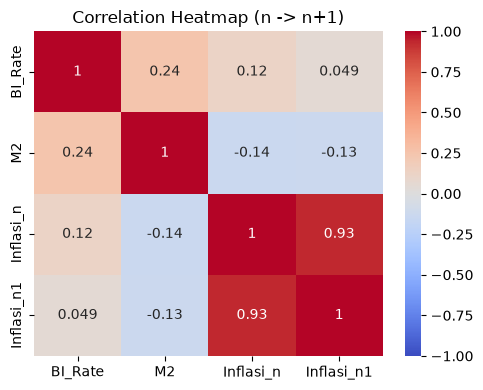

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_viz = df_p.copy()
pred = model.predict(X)

plt.rcParams['figure.dpi'] = 100

# 1) Correlation heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(df_viz[['BI_Rate', 'M2', 'Inflasi_n', 'Inflasi_n1']].corr(), annot=True,
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap (n -> n+1)')
plt.tight_layout()
plt.show()

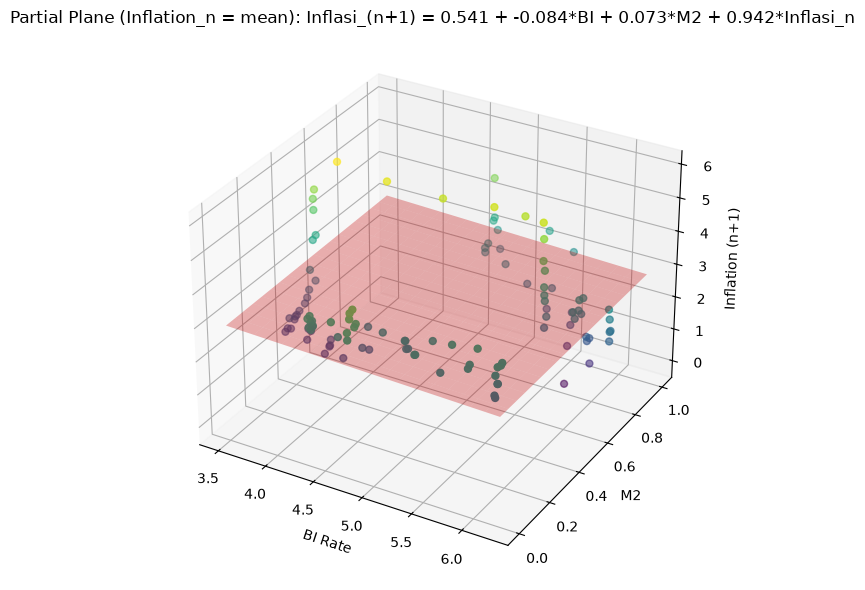

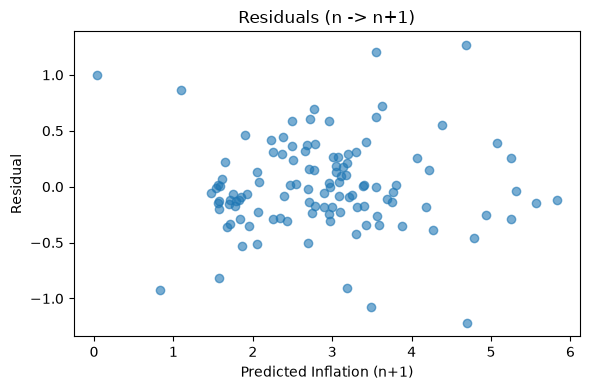

In [31]:
# 3) 3D scatter + partial regression plane: BI Rate & M2 -> Inflation_(n+1),
#    evaluated with Inflation_n held at its mean.
from mpl_toolkits.mplot3d import Axes3D

infl_mean = df_viz['Inflasi_n'].mean()
xx, yy = np.meshgrid(
    np.linspace(df_viz['BI_Rate'].min(), df_viz['BI_Rate'].max(), 20),
    np.linspace(df_viz['M2'].min(), df_viz['M2'].max(), 20)
)
zz = b0 + b1 * xx + b2 * yy + b3 * infl_mean

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_viz['BI_Rate'], df_viz['M2'], y, c=y, cmap='viridis', s=25)
ax.plot_surface(xx, yy, zz, alpha=0.3, color='red')
ax.set_xlabel('BI Rate')
ax.set_ylabel('M2')
ax.set_zlabel('Inflation (n+1)')
ax.set_title('Partial Plane (Inflation_n = mean): Inflasi_(n+1) = %.3f + %.3f*BI + %.3f*M2 + %.3f*Inflasi_n' % (b0, b1, b2, b3))
plt.tight_layout()
plt.show()

# 4) Residuals (error for each data point)
resid = y - pred
plt.figure(figsize=(6, 4))
plt.scatter(pred, resid, alpha=0.6)
plt.xlabel('Predicted Inflation (n+1)')
plt.ylabel('Residual')
plt.title('Residuals (n -> n+1)')
plt.tight_layout()
plt.show()

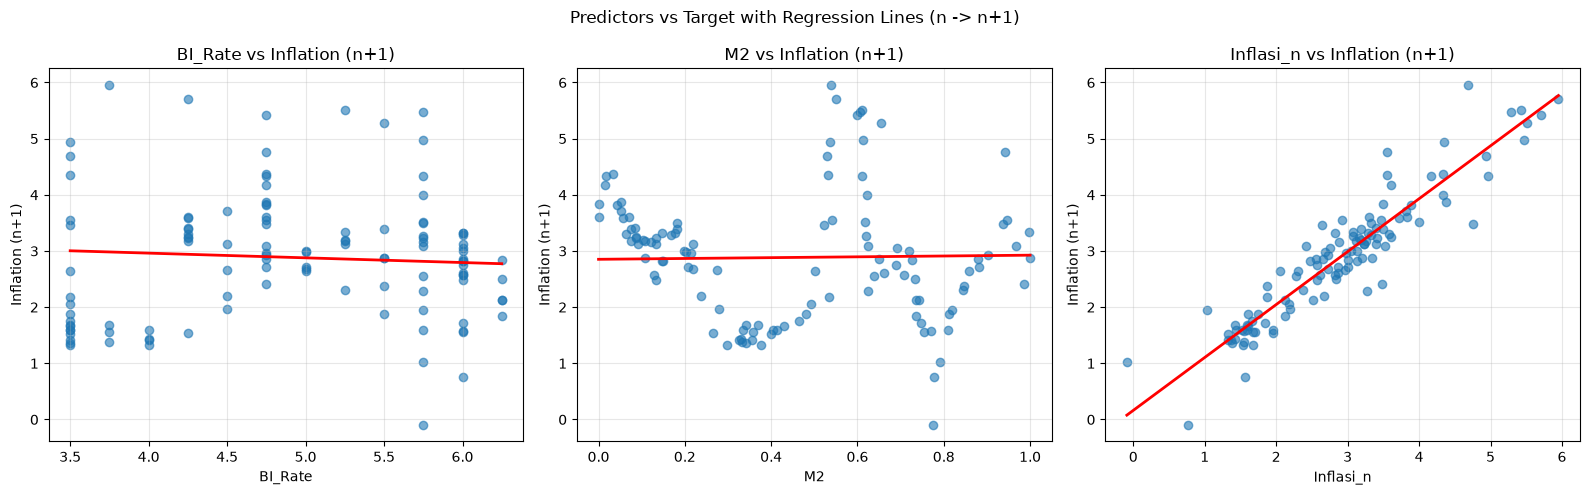

In [32]:
# Plot each predictor (x) vs target (y) with the regression line from the model
# Partial regression line: hold the other predictors at their means.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
preds = ['BI_Rate', 'M2', 'Inflasi_n']
other_means = {p: df_viz[p].mean() for p in preds}

for ax, pred_name in zip(axes, preds):
    xs = np.linspace(df_viz[pred_name].min(), df_viz[pred_name].max(), 50)
    ys = b0 + b1 * other_means['BI_Rate'] + b2 * other_means['M2'] + b3 * other_means['Inflasi_n']
    # slide only the current predictor from its min to max
    ys = ys + ({'BI_Rate': b1, 'M2': b2, 'Inflasi_n': b3}[pred_name] * (xs - other_means[pred_name]))
    ax.scatter(df_viz[pred_name], y, alpha=0.6)
    ax.plot(xs, ys, 'r-', linewidth=2)
    ax.set_xlabel(pred_name)
    ax.set_ylabel('Inflation (n+1)')
    ax.set_title(f'{pred_name} vs Inflation (n+1)')
    ax.grid(alpha=0.3)

fig.suptitle('Predictors vs Target with Regression Lines (n -> n+1)')
plt.tight_layout()
plt.show()

## Summary — Model prediction for Inflation rate at period *n+1*

$$\text{Inflasi}_{n+1} = b_0 + b_1 \cdot \text{BI\_Rate}_n + b_2 \cdot \text{M2}_n + b_3 \cdot \text{Inflasi}_n$$

- **BI Rate coefficient (n)** → how much next-month Inflation moves when this month's BI Rate rises by 1 point (holding the others fixed)
- **M2 coefficient (n)** → how much next-month Inflation moves when normalized M2 rises (holding the others fixed)
- **Inflasi_n coefficient** → how much next-month Inflation moves when current Inflation rises by 1 point (holding the others fixed; autoregressive term)